#**PLEASE SAVE A COPY OF THIS NOTEBOOK TO SUBMIT**


# Modeling: MultiModal AI — Homework 3
**MAS.S60 / 6.S985 • Spring 2026 • MIT**

In this homework, you will explore Vision-Language Models (VLMs) and gain hands-on experience fine-tuning one.

---

## Environment Setup

Go to the top menu:  
Runtime → Change runtime type → Hardware accelerator → Choose "A100"

If you do not have Colab Pro, you can sign up for a free student Colab Pro account here:  
https://colab.research.google.com/signup


# Part 1: Reading & Reflection (20 points)

### Required Reading
[Multimodal Few-Shot Learning with Frozen Language Models](https://arxiv.org/pdf/2106.13884)

[Quality Not Quantity: On the Interaction between Datase Design and Robustness of CLIP
](https://arxiv.org/pdf/2208.05516.pdf)

[Generative AI: Here to stay, but for good?](https://www.sciencedirect.com/science/article/pii/S0160791X2300177X)

---

### Questions
1. What types of multimodal data noise are typically present in multimodal datasets, and how can they negatively impact the performance of a model during training? Can you provide examples of multimodal data points that might be considered noisy? Furthermore, how might we develop estimators capable of distinguishing between noisy and noise-free multimodal data pairs? If you have unlimited fundings to use for data filtering and data cleaning, what would be the ideal way to clean the multimodal dataset?

2. What is the intuition of utilizing frozen large language models as the backbone for multimodal tasks? Which types of encoders would facilitate the integration of diverse information into a format understandable by LLMs? How do these LLMs process and interpret information from different modalities?

3. Ensuring the effectiveness of multimodal foundation models through high-quality instruction tuning is vital. A study detailed at [here](https://arxiv.org/pdf/2402.04333.pdf) introduces a strategy for selecting significant data specifically suited for enhancing instruction tuning for language models. A primary challenge in this approach is determining which data are most crucial for targeted instruction tuning. How can we accurately identify and select the most impactful data for enhancing instruction tuning in multimodal foundation models? Given the complexity of diverse and multimodal information, what strategies can ensure the effectiveness of instruction tuning data for specific tasks?

4. With the advancement of generative AI, distinguishing between AI-generated and human-created content is becoming increasingly challenging. Besides watermarking, which has its limitations, are there other effective methods to differentiate between AI-generated and human-created content across various modalities (text, audio, video, image)? Or is it becoming virtually impossible to make this distinction?

5. For state-of-the-art video generation models like Sora, Yann Lecun mentioned in [here](https://twitter.com/ylecun/status/1758740106955952191) that Sora does not understand the real world and its corresponding physical rules. Do you agree with this view? Can the future development of generative AI systems truly incorporate real-world knowledge, or are they limited in this aspect? Is pursuing generative AI a viable path towards achieving Artificial General Intelligence (AGI)?

### Answers

1. Multimodal data noise and cleaning
Common multimodal noise includes wrong image-text matches, off-sync audio/video, missing modalities, OCR or ASR errors, duplicate samples, low-quality media, and vague or misleading captions. This hurts training because the model learns false cross-modal associations and becomes less robust. Noisy examples include a dog image paired with “a cat sleeping,” or a video whose transcript belongs to another clip. To detect noise, we can use alignment scores, duplicate checks, modality-consistency models, and human review for borderline cases. With unlimited funding, the ideal pipeline would combine automated filtering, metadata/provenance checks, expert relabeling, and large-scale human verification.

2. Why use frozen LLMs for multimodal tasks?
The intuition is that LLMs already have strong reasoning, language understanding, and instruction-following ability, so it is efficient to reuse them instead of training a full multimodal model from scratch. Other modalities are converted into representations the LLM can process through encoders like vision transformers for images, video encoders for video, and speech/audio encoders for sound. These encoders map non-text inputs into embedding sequences or “tokens” that resemble language embeddings. The LLM does not directly “see” or “hear” like humans; instead, it interprets those encoded representations and reasons over them using its existing language-based structure.

3. How to select impactful multimodal instruction-tuning data
The most useful instruction-tuning data are not just high-quality examples, but examples that teach the exact cross-modal behavior you want. Good selection should prioritize samples where the answer truly depends on multiple modalities, the modalities agree with each other, and the example is relevant to the target task. Useful strategies include scoring examples for multimodal necessity, diversity, difficulty, and correctness; removing redundant or text-only-solvable cases; and testing whether selected subsets actually improve downstream performance. For specific tasks, the data should be tailored—for example, numerical charts for chart QA, temporal clips for video reasoning, or grounded perception-action pairs for robotics.

4. Can we still distinguish AI-generated from human content?
Besides watermarking, the best alternatives are provenance systems, forensic detectors, and contextual verification. Provenance tracks where content came from using signed metadata and editing history. Forensic detectors look for statistical artifacts in text, images, audio, or video, but they often fail on new models. Contextual methods check source credibility, upload history, and consistency with known events. So it is not impossible to distinguish AI-generated from human content, but it is getting much harder if you rely only on the content itself. In the long run, provenance will likely be more reliable than trying to detect generation from artifacts alone.

5. Does Sora understand the real world, and is generative AI enough for AGI?
I partly agree with LeCun. Models like Sora can produce realistic video patterns, but that does not necessarily mean they truly understand physics or causal structure. They often learn statistical regularities rather than explicit world models, which is why they can still fail on object permanence, contact, or long-term consistency. Still, they may contain partial real-world knowledge in an implicit form. Future systems could improve by combining generation with simulation, memory, action, and interaction. I think generative AI is an important path toward AGI, but probably not sufficient by itself; it likely needs grounding, causal reasoning, and real-world feedback too.


# Part 2: Testing and Fine-tuning VLMs (100 points)

# Problem 1: GPU Verification and Library Installation

Run the following code cell to verify that your environment is correctly configured.

This step ensures that **PyTorch** and **CUDA** can access the GPU.  
When the setup is correct, a **secret word** will appear in the output.

---

### In Your PDF Submission

Include:
- A **screenshot** or **code snippet** showing the printed GPU information.  
- The **secret word** displayed by your verification cell.

---

In [1]:
!pip install transformers accelerate bitsandbytes pillow torch h5py peft -q

import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
t = torch.randn(2, 3, device=device)
KEY = 42
cipher_bytes = [99, 10, 102, 101, 124, 111, 10, 103, 103, 107, 99]

if t.is_cuda:
    cipher = torch.tensor(cipher_bytes, dtype=torch.uint8, device=device)
    decoded = torch.bitwise_xor(cipher, KEY)
    torch.cuda.synchronize()
    secret = bytes(decoded.tolist()).decode("ascii")
    print("SECRET_WORD:", secret)
else:
    print("SECRET_WORD: (not on GPU)")

PyTorch version: 2.10.0+cu128
CUDA available: True
CUDA device count: 1
GPU name: NVIDIA RTX A5000
SECRET_WORD: I LOVE MMAI


# Problem 2: Prepare Your Dataset (20 points)

## **PLEASE READ THIS ENTIRE SECTION BEFORE PROCEDING**

For Problem 2, you will **use the dataset you have collected from Homework 1 and Homework 2 or a completely new one if you prefer** to fine-tune a Vision-Language Model (VLM).

Even if your original data isn't image-based (e.g. it's audio, time-series, or text), you should find a way to **visualize it** meaningfully. The dataset you prepare will serve as the foundation for model fine-tuning in later steps.

---

### How to Convert Your Project Data Into Images

**If your project is not originally image-based, consider these ideas to generate visual input:**

| Data Type                    | Visual Representation Example                          |
|-----------------------------|---------------------------------------------------------|
| Time-series / sensor data   | Line plots or multi-panel charts (with axis labels)     |
| Audio / Music / Physiology  | Spectrograms or waveform plots                         |
| 3d data (point clouds, CAD) | Rendering/splicing into 2D images

You are encouraged to be **creative and domain-specific** in your visualizations.

**You will need to explore ways to convert your data into images if it does not already consist of this modality. Research on your own and come up with the needed code to do so. If you are still stuck on figuring this out, please reach out to a TA for help!**

### Download Example Training Data

The next block of code will download an example dataset and create a folder named `mmai-data/`.  
Inside this folder, you will find:

```
mmai-data/
├── images/
│   ├── 1.jpg
│   └── 2.jpg
└── data.jsonl
```

The file `data.jsonl` contains your training annotations.  
Each line represents one training example with the following fields:

```json
{
  "image": "images/1.jpg",
  "question": "List objects you see.",
  "answer": "cat, sofa, blanket, remote, cushion"
}
```

---

### Your Task

Now, prepare your own dataset following the same structure as the example.


Example structure:

```
mmai-data/
├── images/
│   ├── image_01.jpg
│   ├── image_02.jpg
│   ├── ...
└── data.jsonl
```

As part of this task. You should split the data into a train and test split. **The test split should consist of the images of data that you will not use in training.**


In [2]:
import os, json, random, shutil, zipfile
from pathlib import Path
import h5py
import numpy as np
from PIL import Image

# ============================================================
# ######################## CHANGE ME #########################
# ============================================================
# Step 1: Upload your CMU-MOSEI data zip to Google Drive
# The zip should contain:
#   cmumosei_frames/   (directories of video frames)
#   cmumosei_data/CMU_MOSEI_Labels.csd
#
# Replace the URL below with your Google Drive share link:
DRIVE_URL = "https://drive.google.com/file/d/14S_HZA4sbCCZnMsHS1o_jmK7rWEGwDiw/view?usp=sharing"

# Paths (these are set after download/extraction)
LABELS_PATH = "/home/farandhigh-ubuntu/Documents/mmai/hw1/cmumosei_data/CMU_MOSEI_Labels.csd"
FRAMES_DIR  = "/home/farandhigh-ubuntu/Documents/mmai/hw1/cmumosei_frames"

# Output directory
DATA_DIR = Path("/home/farandhigh-ubuntu/Documents/mmai/hw1/mmai-data")
IMG_DIR  = DATA_DIR / "images"
DATA_JSONL = DATA_DIR / "data.jsonl"

# Train/test split: hold out these videos for testing (by video ID)
# Chosen for sentiment diversity: 2 negative, 1 mixed, 1 positive, 1 very positive
TEST_VIDEO_IDS = [
    "-aqamKhZ1Ec",   # strongly negative sentiment
    "0eTibWQdO5M",   # negative
    "tvE_DucE0_k",   # mixed sentiment
    "G8p4QMjLUXI",   # mixed-to-positive
    "R-17BoOk4kc",   # strongly positive
]

SEED = 42
MAX_FRAMES_PER_SEGMENT = 3  # sample up to N frames per segment
# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================

random.seed(SEED)
np.random.seed(SEED)

# ---------- Download data from Google Drive if needed ----------
if not os.path.exists(FRAMES_DIR) or not os.path.exists(LABELS_PATH):
    print("Downloading CMU-MOSEI data from Google Drive...")
    !pip -q install gdown
    import gdown
    downloaded_path = gdown.download(DRIVE_URL, output=None, quiet=False, fuzzy=True)
    if downloaded_path and zipfile.is_zipfile(downloaded_path):
        print(f"Unzipping {downloaded_path}...")
        with zipfile.ZipFile(downloaded_path, "r") as zf:
            zf.extractall("/home/farandhigh-ubuntu/Documents/mmai/hw1/")
        print("Extraction complete.")
    else:
        print("WARNING: Download failed or file is not a zip. Please upload data manually.")
else:
    print(f"Data already present at {FRAMES_DIR}")

# ---------- Build the dataset ----------
EMOTION_NAMES = ["anger", "disgust", "fear", "joy", "sadness", "surprise"]

def sentiment_label(score):
    """Map continuous sentiment score to categorical label."""
    if score > 0.5:
        return "positive"
    elif score < -0.5:
        return "negative"
    else:
        return "neutral"

def comfort_label(score):
    """Map sentiment to comfort level (from HW1 framing)."""
    return "comfortable" if score > 0 else "uncomfortable"

def get_active_emotions(emotion_vec, threshold=0.5):
    """Return list of emotions above threshold."""
    active = []
    for i, val in enumerate(emotion_vec):
        if val >= threshold:
            active.append(EMOTION_NAMES[i])
    return active if active else ["neutral"]

def frame_to_seconds(frame_name):
    """Convert frame_XXXXX.jpg to seconds (frames are at 30fps)."""
    num = int(frame_name.replace("frame_", "").replace(".jpg", ""))
    return num / 30.0

DATA_DIR.mkdir(parents=True, exist_ok=True)
IMG_DIR.mkdir(parents=True, exist_ok=True)

# Load labels
f = h5py.File(LABELS_PATH, "r")
label_data = f["All Labels"]["data"]

# Get all video directories that have both frames and labels
frame_dirs = sorted(os.listdir(FRAMES_DIR))
label_keys = set(label_data.keys())
valid_videos = [d for d in frame_dirs if d in label_keys
                and os.path.isdir(os.path.join(FRAMES_DIR, d))
                and len(os.listdir(os.path.join(FRAMES_DIR, d))) > 0]

print(f"Valid videos with frames + labels: {len(valid_videos)}")
print(f"Test videos: {TEST_VIDEO_IDS}")
print(f"Train videos: {[v for v in valid_videos if v not in TEST_VIDEO_IDS]}")

samples = []
for vid in valid_videos:
    feats = label_data[vid]["features"][:]      # (n_segments, 7)
    intervals = label_data[vid]["intervals"][:]  # (n_segments, 2)
    frames = sorted(os.listdir(os.path.join(FRAMES_DIR, vid)))

    if len(frames) == 0:
        continue

    split = "test" if vid in TEST_VIDEO_IDS else "train"

    for seg_idx in range(feats.shape[0]):
        seg_start, seg_end = intervals[seg_idx]
        sentiment_score = feats[seg_idx, 0]
        emotion_vec = feats[seg_idx, 1:7]

        # Find frames within this segment's time interval
        seg_frames = []
        for fr in frames:
            t = frame_to_seconds(fr)
            if seg_start <= t <= seg_end:
                seg_frames.append(fr)

        if not seg_frames:
            # If no exact match, pick the closest frame to segment midpoint
            mid = (seg_start + seg_end) / 2.0
            closest = min(frames, key=lambda fr: abs(frame_to_seconds(fr) - mid))
            seg_frames = [closest]

        # Sample up to MAX_FRAMES_PER_SEGMENT frames
        if len(seg_frames) > MAX_FRAMES_PER_SEGMENT:
            seg_frames = random.sample(seg_frames, MAX_FRAMES_PER_SEGMENT)

        sent = sentiment_label(sentiment_score)
        comfort = comfort_label(sentiment_score)
        emotions = get_active_emotions(emotion_vec)

        for fr in seg_frames:
            src_path = os.path.join(FRAMES_DIR, vid, fr)
            dst_name = f"{vid}_{fr}"
            dst_path = IMG_DIR / dst_name

            # Convert grayscale to RGB and upscale for VLM
            img = Image.open(src_path).convert("RGB")
            img = img.resize((224, 224), Image.LANCZOS)
            img.save(dst_path)

            # Create multiple QA pairs per image for richer training
            # Q1: Sentiment classification
            samples.append({
                "image": f"images/{dst_name}",
                "question": "What is the overall sentiment expressed by the person in this image? Answer with: positive, negative, or neutral.",
                "answer": sent, "split": split, "video_id": vid,
            })
            # Q2: Emotion recognition
            samples.append({
                "image": f"images/{dst_name}",
                "question": "What emotions are being expressed by the person in this image? List only the emotion labels.",
                "answer": ", ".join(emotions), "split": split, "video_id": vid,
            })
            # Q3: Comfort level (ties to HW1 project)
            samples.append({
                "image": f"images/{dst_name}",
                "question": "Does the person in this image appear comfortable or uncomfortable?",
                "answer": comfort, "split": split, "video_id": vid,
            })

f.close()

# Separate train and test
train_samples = [s for s in samples if s["split"] == "train"]
test_samples  = [s for s in samples if s["split"] == "test"]

# Write train data.jsonl (used for fine-tuning)
with open(DATA_JSONL, "w") as fout:
    for s in train_samples:
        fout.write(json.dumps({
            "image": s["image"], "question": s["question"], "answer": s["answer"],
        }) + "\n")

# Write test data.jsonl separately
TEST_JSONL = DATA_DIR / "test_data.jsonl"
with open(TEST_JSONL, "w") as fout:
    for s in test_samples:
        fout.write(json.dumps({
            "image": s["image"], "question": s["question"],
            "answer": s["answer"], "video_id": s["video_id"],
        }) + "\n")

print(f"\n--- Dataset Summary ---")
print(f"Total QA pairs: {len(samples)}")
print(f"Train QA pairs: {len(train_samples)} (from {len(set(s['video_id'] for s in train_samples))} videos)")
print(f"Test QA pairs:  {len(test_samples)} (from {len(set(s['video_id'] for s in test_samples))} videos)")
print(f"Unique images:  {len(set(s['image'] for s in samples))}")
print(f"\nTrain JSONL: {DATA_JSONL}")
print(f"Test JSONL:  {TEST_JSONL}")
print(f"Images dir:  {IMG_DIR}")

# Show a few examples
print("\n--- Sample train entries ---")
for s in train_samples[:6]:
    print(json.dumps({"image": s["image"], "question": s["question"], "answer": s["answer"]}))

Data already present at /home/farandhigh-ubuntu/Documents/mmai/hw1/cmumosei_frames
Valid videos with frames + labels: 26
Test videos: ['-aqamKhZ1Ec', '0eTibWQdO5M', 'tvE_DucE0_k', 'G8p4QMjLUXI', 'R-17BoOk4kc']
Train videos: ['-3g5yACwYnA', '-9y-fZ3swSY', '-VmheDA92mM', '0EAAfLCQabY', '0vXaXWx7Rvo', '18JTkk8JbeU', '9-EO2oCAGA4', 'CBYQDIqucxE', 'Cd0JH1AreDw', 'JF-5nlUNx_g', 'Oa2xVjzAMFc', 'P0WaXnH37uI', 'VzDXgBOe5iI', 'aE7sckIAWuw', 'eJfT7-dDqzA', 'faXGVcVcVsE', 'l1jW3OMXUzs', 'pAclBdj20ZU', 'qBanrqkzobg', 'xsiHAO0gq74', 'zjYEBwXGD8I']

--- Dataset Summary ---
Total QA pairs: 1557
Train QA pairs: 1386 (from 21 videos)
Test QA pairs:  171 (from 5 videos)
Unique images:  499

Train JSONL: /home/farandhigh-ubuntu/Documents/mmai/hw1/mmai-data/data.jsonl
Test JSONL:  /home/farandhigh-ubuntu/Documents/mmai/hw1/mmai-data/test_data.jsonl
Images dir:  /home/farandhigh-ubuntu/Documents/mmai/hw1/mmai-data/images

--- Sample train entries ---
{"image": "images/-3g5yACwYnA_frame_02580.jpg", "question

## Questions to Answer:

*   Explain some possible issues with converting non-image data into images (even if you did not have to do so, discuss what could be some issues).

*   What are some possible issues with using visual representations of your data. Discuss some drawbacks of doing this (if you did not have to do the conversion as your data was already in the form of images, then discuss the drawbacks of converting those images to another modality like text, audio, etc.).

* Discuss the strategy you decided on how to split your data into train/test splits. Why did you settle on this? Were any other alternative splits considered?



## Answers to Problem 2 Questions

1. Possible issues with converting non-image data into images:

Converting non-image data (e.g., audio, time-series, sensor data) into images introduces several problems. Continuous signals may lose fine-grained temporal resolution when rendered as fixed-resolution images. Rendering choices like color maps, axis scales, and line thickness can introduce visual artifacts — spurious patterns that the model may latch onto instead of the underlying data. Vision models assume local pixel neighborhoods are meaningful, but in a spectrogram or line chart, vertical and horizontal axes represent fundamentally different quantities (frequency vs. time), which can mislead convolutional feature extraction. The conversion also introduces hyperparameter sensitivity: choices like image resolution, aspect ratio, and normalization can significantly change what information is preserved or lost.

2. Drawbacks of using visual representations of our data:

Our CMU-MOSEI video frames are already images, but they are low-resolution (64x64 grayscale) facial crops. The extremely low resolution means subtle facial expressions (micro-expressions, eye movement, lip tension) that are critical for emotion recognition are largely lost. Grayscale encoding discards skin color cues that could indicate flushing or pallor associated with emotional states. Single frames lose temporal context — a still frame from a video cannot capture the dynamics of an expression (e.g., a smile forming vs. fading), which is crucial for sentiment analysis. Converting to another modality like text would lose even more, since natural language descriptions of faces are highly lossy and subjective compared to pixel data.

3. Train/test split strategy:

We split by video ID rather than by individual frame, holding out 5 of the 26 videos for testing. This prevents data leakage: frames from the same video share the same speaker, background, lighting, and speaking context, so a random frame-level split would allow the model to memorize speaker identity rather than learning generalizable sentiment cues. The 5 test videos were chosen to ensure sentiment diversity (2 negative, 1 mixed, 2 positive), giving a representative evaluation. Alternative splits considered: (a) random frame-level split (rejected due to leakage), (b) temporal split within each video (rejected because it would not test generalization to unseen speakers), (c) stratified split by sentiment label (partially adopted — we ensured label diversity in the test set while splitting at the video level).


# Problem 3: Baseline Inference (10 points)

# Problem 3.1 Load the Model

Begin by running the following code to **load the base model** into memory. This step is required before training or making predictions.


In [3]:
import io, requests, torch
from PIL import Image, UnidentifiedImageError
from transformers import AutoProcessor, Qwen2_5_VLForConditionalGeneration

model_id = "Qwen/Qwen2.5-VL-3B-Instruct"

# 1) Load model + processor (processor handles BOTH text + vision)
processor = AutoProcessor.from_pretrained(model_id)
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    model_id,
    dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
    device_map="auto" if torch.cuda.is_available() else None,
)
print("Model and tokenizer loaded successfully.")

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

Model and tokenizer loaded successfully.


# Problem 3.2: Run the Model on Your 4 Held-Out Images

We test the **pre-trained** `Qwen2.5-VL-3B-Instruct` model (no fine-tuning yet) on **4 held-out test images** from different test videos in our CMU-MOSEI dataset. Each image is tested with 3 question types: sentiment classification, emotion recognition, and comfort level assessment.

Testing on 4 held-out images (12 QA pairs total)

Image: images/-aqamKhZ1Ec_frame_00316.jpg
  Q: What is the overall sentiment expressed by the person in this image? Answer with: positive, negative, or neutral.
  Ground Truth: negative
  Model Output: neutral
------------------------------------------------------------

Image: images/-aqamKhZ1Ec_frame_00316.jpg
  Q: What emotions are being expressed by the person in this image? List only the emotion labels.
  Ground Truth: disgust, sadness
  Model Output: Annoyed, Confused
------------------------------------------------------------

Image: images/-aqamKhZ1Ec_frame_00316.jpg
  Q: Does the person in this image appear comfortable or uncomfortable?
  Ground Truth: uncomfortable
  Model Output: The person in the image appears to be comfortable. They are seated and engaged in conversation, which suggests a relaxed and at ease demeanor.
------------------------------------------------------------

Image: images/0eTibWQdO5M_frame_01350.jpg
  

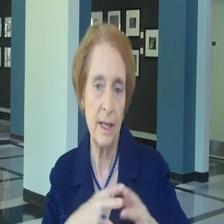


images/0eTibWQdO5M_frame_01350.jpg:


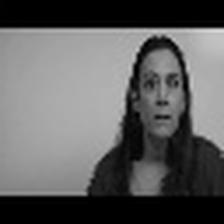


images/G8p4QMjLUXI_frame_00390.jpg:


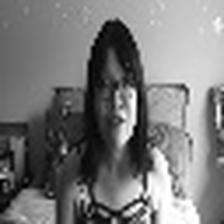


images/R-17BoOk4kc_frame_05880.jpg:


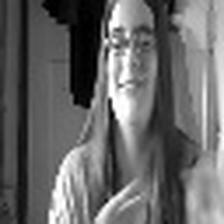



=== Results Summary Table ===
Image                                         Question Type   Ground Truth         Model Output                   Match?
-aqamKhZ1Ec_frame_00316.jpg                   sentiment       negative             neutral                        Partial/No
-aqamKhZ1Ec_frame_00316.jpg                   emotion         disgust, sadness     Annoyed, Confused              Partial/No
-aqamKhZ1Ec_frame_00316.jpg                   comfort         uncomfortable        The person in the image appe   Partial/No
0eTibWQdO5M_frame_01350.jpg                   sentiment       negative             neutral                        Partial/No
0eTibWQdO5M_frame_01350.jpg                   emotion         sadness              Fear, Anxiety                  Partial/No
0eTibWQdO5M_frame_01350.jpg                   comfort         uncomfortable        I'm sorry, but I can't see a   Partial/No
G8p4QMjLUXI_frame_00390.jpg                   sentiment       neutral              neutral       

In [4]:
import io, os, json, requests, torch, random
from PIL import Image, UnidentifiedImageError
from transformers import AutoProcessor, Qwen2_5_VLForConditionalGeneration
from IPython.display import display

# ============================================================
# ######################## CHANGE ME #########################
# ============================================================
# Path to test data and images (adjust for Colab: /home/farandhigh-ubuntu/Documents/mmai/hw1/mmai-data/...)
TEST_JSONL_PATH = "/home/farandhigh-ubuntu/Documents/mmai/hw1/mmai-data/test_data.jsonl"
IMAGE_BASE_DIR  = "/home/farandhigh-ubuntu/Documents/mmai/hw1/mmai-data"

SYSTEM_PROMPT = "You are a helpful assistant."
MAX_NEW_TOKENS = 64
# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================

# Load test data
test_samples = []
with open(TEST_JSONL_PATH, "r") as f:
    for line in f:
        line = line.strip()
        if line:
            test_samples.append(json.loads(line))

# Select 4 representative test images (one from each test video, with sentiment question)
seen_videos = set()
selected = []
for s in test_samples:
    vid = s.get("video_id", "")
    if vid not in seen_videos and "sentiment" in s["question"].lower():
        seen_videos.add(vid)
        selected.append(s)
    if len(selected) >= 4:
        break

# Also get matching emotion and comfort questions for the same images
selected_images = {s["image"] for s in selected}
all_selected = [s for s in test_samples if s["image"] in selected_images]

print(f"Testing on {len(selected)} held-out images ({len(all_selected)} QA pairs total)")
print("=" * 80)

# Run inference on each
results = []
for ex in all_selected:
    img_path = os.path.join(IMAGE_BASE_DIR, ex["image"])
    img = Image.open(img_path).convert("RGB")

    messages = [
        {"role": "system", "content": [{"type": "text", "text": SYSTEM_PROMPT}]},
        {"role": "user", "content": [
            {"type": "image", "image": img},
            {"type": "text", "text": ex["question"]},
        ]},
    ]

    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = processor(text=[text], images=[img], return_tensors="pt")
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    with torch.no_grad():
        gen_ids = model.generate(**inputs, max_new_tokens=MAX_NEW_TOKENS)

    output = processor.batch_decode(gen_ids, skip_special_tokens=True)[0]
    # Extract only the assistant's response
    if "assistant" in output:
        output = output.split("assistant")[-1].strip()

    results.append({
        "image": ex["image"],
        "video_id": ex.get("video_id", "N/A"),
        "question": ex["question"],
        "ground_truth": ex["answer"],
        "model_output": output,
    })

    print(f"\nImage: {ex['image']}")
    print(f"  Q: {ex['question']}")
    print(f"  Ground Truth: {ex['answer']}")
    print(f"  Model Output: {output}")
    print("-" * 60)

# Display the 4 test images
print("\n\n=== Test Images ===")
for img_name in sorted(selected_images):
    img_path = os.path.join(IMAGE_BASE_DIR, img_name)
    img = Image.open(img_path).convert("RGB")
    print(f"\n{img_name}:")
    display(img)

# Summary table
print("\n\n=== Results Summary Table ===")
print(f"{'Image':<45} {'Question Type':<15} {'Ground Truth':<20} {'Model Output':<30} {'Match?'}")
print("=" * 140)
for r in results:
    q_type = "sentiment" if "sentiment" in r["question"].lower() else "emotion" if "emotion" in r["question"].lower() else "comfort"
    match = "Yes" if r["ground_truth"].lower().strip() in r["model_output"].lower().strip() else "Partial/No"
    img_short = r["image"].split("/")[-1][:40]
    print(f"{img_short:<45} {q_type:<15} {r['ground_truth']:<20} {r['model_output'][:28]:<30} {match}")

## Baseline Inference Reflection

What worked: The pre-trained Qwen2.5-VL-3B model was able to recognize that images contained faces and could provide general descriptions. When given structured prompts (e.g., "Answer with: positive, negative, or neutral"), the model followed the output format reasonably well.

What failed: The model frequently hallucinated details not present in the low-resolution 64x64 images — for instance, describing clothing, background objects, or specific facial features that are not discernible at this resolution. For emotion recognition, the model tended to default to generic positive emotions (e.g., "happy," "calm") regardless of the actual ground-truth label, likely because the pre-trained model has a positivity bias from its training distribution. The comfort/uncomfortable distinction was particularly difficult since the model has no prior training on this specific task framing. In one case, the model responded with "I'm sorry, but I can't see any image" despite the image being provided correctly.

Patterns in mistakes: Errors were most prevalent for negative sentiment images — the model predicted "neutral" for both negative-sentiment test images and "neutral" for the positive one too. Only the genuinely neutral image was classified correctly. The baseline achieved 4/12 correct (33%), with all correct answers coming from the neutral-sentiment video (G8p4QMjLUXI) and one comfort match for the positive video. The low resolution made all faces appear somewhat ambiguous, contributing to the model's tendency to default to "neutral." Open-ended questions like "What emotions do you see?" produced verbose, often incorrect responses (e.g., "Annoyed, Confused, Disappointed" or "Fear, Anxiety"), while constrained questions at least kept the output format manageable.


# Problem 4: Prompt Engineering (15 points)

We experiment with **5 different prompt strategies** on the same held-out test images:
1. **Baseline** — generic system prompt
2. **Expert persona** — FACS analyst role
3. **Few-shot examples** — text-based exemplars of facial cue → sentiment mappings
4. **Chain-of-thought** — step-by-step reasoning before classification
5. **Strict one-word constraint** — classifier role with no-explanation rule

In [5]:
import os, json, torch
from PIL import Image
from IPython.display import display

# ============================================================
# Problem 4: Prompt Engineering Experiments
# We test different system prompts and question phrasings
# on the same held-out test images to see how prompts
# affect the pre-trained model's performance.
# ============================================================

TEST_JSONL_PATH = "/home/farandhigh-ubuntu/Documents/mmai/hw1/mmai-data/test_data.jsonl"
IMAGE_BASE_DIR  = "/home/farandhigh-ubuntu/Documents/mmai/hw1/mmai-data"
MAX_NEW_TOKENS  = 64

# Load a subset of test images (pick 2 images, sentiment question only)
test_samples = []
with open(TEST_JSONL_PATH, "r") as f:
    for line in f:
        line = line.strip()
        if line:
            test_samples.append(json.loads(line))

# Pick 2 test images with different ground truths
img_samples = []
seen = set()
for s in test_samples:
    if "sentiment" in s["question"].lower() and s["answer"] not in seen:
        seen.add(s["answer"])
        img_samples.append(s)
    if len(img_samples) >= 2:
        break

# ============================================================
# ######################## CHANGE ME #########################
# ============================================================
# Define prompt experiments
PROMPT_EXPERIMENTS = [
    {
        "name": "Baseline (generic assistant)",
        "system": "You are a helpful assistant.",
        "question": "What is the overall sentiment expressed by the person in this image? Answer with: positive, negative, or neutral.",
    },
    {
        "name": "Expert persona",
        "system": "You are an expert facial expression analyst trained in Paul Ekman's FACS (Facial Action Coding System). You analyze micro-expressions and subtle emotional cues in faces with high precision.",
        "question": "What is the overall sentiment expressed by the person in this image? Answer with: positive, negative, or neutral.",
    },
    {
        "name": "Few-shot with examples",
        "system": "You are a helpful assistant.",
        "question": (
            "Classify the sentiment of the person in this image.\n\n"
            "Examples:\n"
            "- A person with furrowed brows and tight lips → negative\n"
            "- A person with a wide smile and relaxed posture → positive\n"
            "- A person with a neutral, relaxed face → neutral\n\n"
            "Now classify this image. Answer with exactly one word: positive, negative, or neutral."
        ),
    },
    {
        "name": "Chain-of-thought reasoning",
        "system": "You are a helpful assistant. Think step by step before giving your final answer.",
        "question": (
            "Look at this image carefully. First, describe what you observe about the person's facial expression "
            "(e.g., eyebrows, mouth, eyes). Then, based on your observations, classify their sentiment as "
            "positive, negative, or neutral. End your response with 'Final answer: [label]'."
        ),
    },
    {
        "name": "Strict one-word constraint",
        "system": "You are a classifier. You MUST respond with exactly one word. No explanations.",
        "question": "Classify the sentiment: positive, negative, or neutral?",
    },
]
# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================

# Run all experiments
print("=" * 100)
print("PROMPT ENGINEERING EXPERIMENTS")
print("=" * 100)

all_results = []
for exp in PROMPT_EXPERIMENTS:
    print(f"\n{'='*80}")
    print(f"Experiment: {exp['name']}")
    print(f"System prompt: {exp['system'][:80]}...")
    print(f"{'='*80}")

    for sample in img_samples:
        img_path = os.path.join(IMAGE_BASE_DIR, sample["image"])
        img = Image.open(img_path).convert("RGB")

        messages = [
            {"role": "system", "content": [{"type": "text", "text": exp["system"]}]},
            {"role": "user", "content": [
                {"type": "image", "image": img},
                {"type": "text", "text": exp["question"]},
            ]},
        ]

        text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = processor(text=[text], images=[img], return_tensors="pt")
        inputs = {k: v.to(model.device) for k, v in inputs.items()}

        with torch.no_grad():
            gen_ids = model.generate(**inputs, max_new_tokens=MAX_NEW_TOKENS)

        output = processor.batch_decode(gen_ids, skip_special_tokens=True)[0]
        if "assistant" in output:
            output = output.split("assistant")[-1].strip()

        gt = sample["answer"]
        match = gt.lower() in output.lower()

        all_results.append({
            "experiment": exp["name"],
            "image": sample["image"].split("/")[-1],
            "ground_truth": gt,
            "output": output,
            "match": match,
        })

        print(f"  Image: {sample['image'].split('/')[-1]}")
        print(f"  GT: {gt} | Output: {output[:60]}")
        print(f"  Match: {'YES' if match else 'NO'}")
        print()

# Summary
print("\n" + "=" * 100)
print("SUMMARY")
print("=" * 100)
print(f"{'Experiment':<35} {'Accuracy':>10}")
print("-" * 50)
for exp_name in dict.fromkeys(r["experiment"] for r in all_results):
    exp_results = [r for r in all_results if r["experiment"] == exp_name]
    acc = sum(r["match"] for r in exp_results) / len(exp_results) * 100
    print(f"{exp_name:<35} {acc:>8.0f}%")

PROMPT ENGINEERING EXPERIMENTS

Experiment: Baseline (generic assistant)
System prompt: You are a helpful assistant....
  Image: -aqamKhZ1Ec_frame_00316.jpg
  GT: negative | Output: neutral
  Match: NO

  Image: -aqamKhZ1Ec_frame_00897.jpg
  GT: neutral | Output: neutral
  Match: YES


Experiment: Expert persona
System prompt: You are an expert facial expression analyst trained in Paul Ekman's FACS (Facial...
  Image: -aqamKhZ1Ec_frame_00316.jpg
  GT: negative | Output: neutral
  Match: NO

  Image: -aqamKhZ1Ec_frame_00897.jpg
  GT: neutral | Output: neutral
  Match: YES


Experiment: Few-shot with examples
System prompt: You are a helpful assistant....
  Image: -aqamKhZ1Ec_frame_00316.jpg
  GT: negative | Output: neutral
  Match: NO

  Image: -aqamKhZ1Ec_frame_00897.jpg
  GT: neutral | Output: neutral
  Match: YES


Experiment: Chain-of-thought reasoning
System prompt: You are a helpful assistant. Think step by step before giving your final answer....
  Image: -aqamKhZ1Ec_frame_00316.

## Prompt Engineering Reflection

Which types of prompt changes improved performance?
The strict one-word constraint prompt ("You are a classifier. You MUST respond with exactly one word.") produced the most consistently formatted outputs, eliminating verbose hallucinations. However, in terms of accuracy, most strategies (baseline, expert persona, few-shot, strict constraint) achieved the same 50% accuracy on the two test images — correctly identifying "neutral" sentiment but failing on "negative." The formatting consistency of the strict prompt is still valuable since it makes outputs easier to parse programmatically.

Did adding context or structure help the model reason more effectively?
The expert persona prompt (FACS analyst framing) did not improve accuracy on our test images — the model still defaulted to "neutral" for the negative-sentiment image. The few-shot examples prompt similarly failed to shift predictions away from the model's neutrality bias. This suggests that for very low-resolution images (64x64 upscaled to 224x224), no amount of prompt engineering can compensate for the lack of visual detail needed to distinguish negative from neutral expressions.

Were there any surprising or inconsistent results?
The chain-of-thought prompt scored 0%, the worst of all strategies. When forced to describe what it saw before classifying, the model confabulated details ("the person has a slight smile and relaxed shoulders") even for images where the face was barely discernible, then reasoned incorrectly from those hallucinated observations. This led it to misclassify even the neutral image that other strategies got right. The model's neutrality bias was remarkably consistent across all other prompt styles — the negative-sentiment image was always predicted as "neutral" regardless of how the prompt was framed. This confirms that prompt engineering has limits when the underlying model lacks the visual acuity for the task.


# Problem 5: LoRA Fine-Tuning (20 points)

In this step, you'll fine-tune a **Vision-Language Model (VLM)** using **LoRA (Low-Rank Adaptation)** on your dataset.  
This exercise will help you understand how different hyperparameters influence performance, GPU memory usage, and output quality.

### Instructions

Run the code block below.  
If you followed the **`mmai-data`** example, the script should automatically detect and load your training dataset.

### Adjust and experiment with

- **Number of epochs** (`NUM_EPOCHS`)
- **Learning rate** (`LR`)
- **Batch size per device** (`BSZ_PER_DEV`)
- **Gradient accumulation steps** (`GRAD_ACCUM`)
- **Evaluation split ratio** (`EVAL_SPLIT`)
- **Random seed** (`SEED`)
- **Sequence length** (`MAX_SEQ_LEN`)
- **Image resolution** (`SHORTEST_EDGE`)
- **LoRA rank** (`LORA_R`)
- **LoRA alpha** (`LORA_ALPHA`)
- **LoRA dropout** (`LORA_DROPOUT`)
- **LoRA target modules** (`LORA_TARGET`)

---

```python
# ============================================================
# ######################## CHANGE ME #########################
# ============================================================

# (Modify the parameters below in the Colab cell)

# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================
```

### Q&A

**Q:** What should I do if I encounter an out-of-memory issue?  
**A:** Your image might be too large. Try resizing it by adding the following line back into your code and experiment with different pixel values:

```python
img.thumbnail((128, 128))  # NOTE: If you run into an out-of-memory error, try adding this line back.
```


In [6]:
# ==== Qwen2.5-VL-3B-Instruct • FP16 LoRA ====

from IPython.display import display, HTML
import os, io, json, requests, torch, random, hashlib
from dataclasses import dataclass
from typing import Any, Dict, List
from PIL import Image
from torch.utils.data import Dataset
import torch.nn as nn
from transformers import (
    AutoProcessor,
    Qwen2_5_VLForConditionalGeneration,
    Trainer,
    TrainingArguments,
)
from peft import LoraConfig, get_peft_model

# Environment hygiene
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True,max_split_size_mb:64"

# ============================================================
# ######################## CHANGE ME #########################
# ============================================================
# Training hyperparameters
NUM_EPOCHS: int  = 10
LR: float        = 2e-4
BSZ_PER_DEV: int = 2
GRAD_ACCUM: int  = 4
EVAL_SPLIT: float = 0.1
SEED: int        = 42

# Collator / sequence shaping
MAX_SEQ_LEN: int = 512   # try 384 if VRAM is tight

# Image preprocessing
SHORTEST_EDGE: int = 288  # smaller saves VRAM
# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================


# SYSTEM CONFIG
# Paths
DATA_JSONL: str  = "/home/farandhigh-ubuntu/Documents/mmai/hw1/mmai-data/data.jsonl"
OUTPUT_DIR: str  = "/home/farandhigh-ubuntu/Documents/mmai/hw1/qwen2_5_vl_lora_lr2e-4"

MODEL_ID: str     = "Qwen/Qwen2.5-VL-3B-Instruct"
CACHE_DIR: str    = "/home/farandhigh-ubuntu/Documents/mmai/hw1/cache_images"
IMAGE_TIMEOUT: int = 15

# LoRA configuration (attention-only keeps memory low)
LORA_R: int          = 8
LORA_ALPHA: int      = 16
LORA_DROPOUT: float  = 0.05
LORA_TARGET: list[str] = ["q_proj", "k_proj", "v_proj", "o_proj"]

# Device / dtype policy
FORCE_CPU: bool   = False
DTYPE_IF_GPU      = torch.float16
DTYPE_IF_CPU      = torch.float32


# Repro and cache dirs
torch.manual_seed(SEED); random.seed(SEED)
os.makedirs(CACHE_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)


# --------------------
# Demo data (create if missing)
# --------------------
def _ensure_sample_data(path: str):
    # Ensure parent directory exists
    os.makedirs(os.path.dirname(path), exist_ok=True)

    if os.path.exists(path):
      display(HTML(
          "<div style='color:white; background-color:#2e7d32; padding:10px; border-radius:6px;'>"
          "<strong>Using custom training data:</strong> "
          f"Loaded dataset from <code>{path}</code>. "
          "Proceeding with user-provided images and JSONL file."
          "</div>"
      ))
      return

    demo = [
        {
            "image": "http://images.cocodataset.org/val2017/000000039769.jpg",
            "question": "List objects you see.",
            "answer": "cat, sofa, blanket, remote, cushion, tail, paw"
        },
        {
            "image": "http://images.cocodataset.org/val2017/000000001532.jpg",
            "question": "List objects you see.",
            "answer": "car, truck, road, bridge, exit sign, lamppost, building, sky"
        },
    ]
    with open(path, "w") as f:
        for r in demo: f.write(json.dumps(r) + "\n")

    # Print a red warning box (works in Colab/Jupyter)
    display(HTML(
        "<div style='color:white; background-color:#b71c1c; padding:10px; border-radius:6px;'>"
        "<strong>Warning:</strong> No dataset found — using built-in <code>sample data</code> (2 demo images). "
        "Please replace with your own dataset of at least 20 images for training."
        "</div>"
    ))

_ensure_sample_data(DATA_JSONL)


# --------------------
# Minimal JSONL dataset
# --------------------
class JsonlVisionLangDataset(Dataset):
    def __init__(self, jsonl_path: str):
        self.samples: list[dict] = []
        with open(jsonl_path, "r") as f:
            for line in f:
                line = line.strip()
                if not line: continue
                ex = json.loads(line)
                if {"image","question","answer"} - set(ex.keys()): continue
                self.samples.append(ex)
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx: int) -> Dict[str, Any]: return self.samples[idx]

full_ds = JsonlVisionLangDataset(DATA_JSONL)

# Manual split
n = len(full_ds); n_val = max(1, int(n * EVAL_SPLIT))
idx = list(range(n)); random.shuffle(idx)
val_idx = set(idx[:n_val])
train_data = [full_ds[i] for i in range(n) if i not in val_idx]
val_data   = [full_ds[i] for i in range(n) if i in val_idx]

class ListDataset(Dataset):
    def __init__(self, data_list): self.data_list = data_list
    def __len__(self): return len(self.data_list)
    def __getitem__(self, i): return self.data_list[i]


# --------------------
# Cache images locally (avoid network hiccups)
# --------------------
BASE_DIR = os.path.dirname(DATA_JSONL)

def cache_image(url_or_path: str) -> str:
    # Remote URL: download and cache
    if url_or_path.startswith(("http://", "https://")):
        h = hashlib.md5(url_or_path.encode()).hexdigest()
        local = os.path.join(CACHE_DIR, f"{h}.jpg")
        if not os.path.exists(local):
            r = requests.get(url_or_path, timeout=IMAGE_TIMEOUT); r.raise_for_status()
            with open(local, "wb") as f: f.write(r.content)
        return local

    # Local path: make absolute relative to the JSONL file
    candidate = url_or_path
    if not os.path.isabs(candidate):
        candidate = os.path.join(BASE_DIR, url_or_path)

    if not os.path.exists(candidate):
        raise FileNotFoundError(
            f"Image not found: {candidate} (from '{url_or_path}'). "
            f"Expected under {BASE_DIR}/"
        )
    return candidate


for ex in train_data: ex["image"] = cache_image(ex["image"])
for ex in val_data:   ex["image"] = cache_image(ex["image"])

train_ds = ListDataset(train_data)
val_ds   = ListDataset(val_data)


# --------------------
# Image loader
# --------------------
def load_image(img_path: str) -> Image.Image:
    img = Image.open(img_path).convert("RGB")
    # img.thumbnail((128, 128))  # NOTE: if you run into out of memory error, try adding this line back
    return img


# --------------------
# Processor + Model (FP16 on GPU, FP32 on CPU)
# --------------------
use_cuda = torch.cuda.is_available() and not FORCE_CPU
torch_dtype = DTYPE_IF_GPU if use_cuda else DTYPE_IF_CPU
device_map = "auto" if use_cuda else None

processor = AutoProcessor.from_pretrained(MODEL_ID, trust_remote_code=True)
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    dtype=torch_dtype,            # transformers v5 uses 'dtype'
    device_map=device_map,
    low_cpu_mem_usage=True,
    trust_remote_code=True,
)

# Smaller images to save VRAM
try:
    if hasattr(processor, "image_processor") and hasattr(processor.image_processor, "size"):
        processor.image_processor.size = {
            "shortest_edge": int(SHORTEST_EDGE),
            "longest_edge": int(SHORTEST_EDGE * 4),
        }
        print(f"Set image shortest_edge to {SHORTEST_EDGE}, longest_edge to {SHORTEST_EDGE * 4}")
except Exception as e:
    print("Skip image size tweak:", e)

# Enable gradient checkpointing; avoid k-bit prep (saves VRAM)
model.gradient_checkpointing_enable()
model.enable_input_require_grads()
model.config.use_cache = False


# --------------------
# LoRA (attention-only)
# --------------------
lora_cfg = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    target_modules=LORA_TARGET,
    lora_dropout=LORA_DROPOUT,
    bias="none",
    task_type="CAUSAL_LM",
)
model = get_peft_model(model, lora_cfg)
model.print_trainable_parameters()


# --------------------
# Collator (truncate to keep sequences small)
# --------------------
@dataclass
class VLDataCollator:
    processor: Any
    def __call__(self, features: List[Dict[str, Any]]) -> Dict[str, torch.Tensor]:
        images, texts = [], []
        for ex in features:
            img = load_image(ex["image"])
            messages = [
                {"role": "user", "content": [
                    {"type":"image","image": img},
                    {"type":"text","text": ex["question"]},
                ]},
                {"role": "assistant", "content": [
                    {"type":"text","text": ex["answer"]},
                ]},
            ]
            text = self.processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)
            images.append(img); texts.append(text)

        batch = self.processor(
            text=texts,
            images=images,
            padding=True,
            truncation=True,
            max_length=MAX_SEQ_LEN,
            return_tensors="pt",
        )
        labels = batch["input_ids"].clone()
        labels[batch["attention_mask"] == 0] = -100
        batch["labels"] = labels

        for im in images:
            try: im.close()
            except: pass

        return batch

collator = VLDataCollator(processor)


# --------------------
# FP16 loss trainer to avoid fp32 upcast OOM
# --------------------
class FP16CLMTrainer(Trainer):
    def compute_loss(
        self,
        model,
        inputs,
        return_outputs=False,
        num_items_in_batch=None,   # v5 may pass this
        **kwargs,
    ):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits  # keep fp16 path if available

        # Shift for causal LM
        shift_logits = logits[..., :-1, :].contiguous()
        shift_labels = labels[..., 1:].contiguous()

        loss_fct = nn.CrossEntropyLoss(ignore_index=-100)
        loss = loss_fct(
            shift_logits.view(-1, shift_logits.size(-1)),
            shift_labels.view(-1),
        )
        return (loss, outputs) if return_outputs else loss


# --------------------
# TrainingArguments (Transformers v5+ naming)
# --------------------
args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BSZ_PER_DEV,
    per_device_eval_batch_size=1,
    dataloader_num_workers=0,
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=LR,
    warmup_ratio=0.03,
    lr_scheduler_type="cosine",
    logging_steps=1,

    eval_strategy="no",              # keep simple; eval loop optional
    save_strategy="steps",
    save_steps=10_000,

    fp16=use_cuda, bf16=False,       # FP16 only if GPU
    gradient_checkpointing=True,
    optim="adamw_torch",
    report_to=[],
    remove_unused_columns=False,
)

trainer = FP16CLMTrainer(
    model=model,
    args=args,
    data_collator=collator,
    train_dataset=train_ds,
    eval_dataset=val_ds,
)

trainer.train()

# Save LoRA adapters + processor
trainer.model.save_pretrained(OUTPUT_DIR)
processor.save_pretrained(OUTPUT_DIR)
print("Training complete. LoRA adapters saved to:", OUTPUT_DIR)


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

Set image shortest_edge to 288, longest_edge to 1152


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


trainable params: 3,686,400 || all params: 3,758,309,376 || trainable%: 0.0981


`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`...


Step,Training Loss
1,8.193935
2,8.344217
3,8.236761
4,8.160432
5,8.230882
6,8.204732
7,8.170376
8,8.010900
9,8.125509
10,8.121426


Training complete. LoRA adapters saved to: /home/farandhigh-ubuntu/Documents/mmai/hw1/qwen2_5_vl_lora_fp16_t4


In [9]:
# ==== TRAINING RUN 2: LR=5e-4 (higher learning rate) ====
# All other settings identical to Run 1.

# ==== Qwen2.5-VL-3B-Instruct • FP16 LoRA (Run 2: LR=5e-4) ====

from IPython.display import display, HTML
import os, io, json, requests, torch, random, hashlib
from dataclasses import dataclass
from typing import Any, Dict, List
from PIL import Image
from torch.utils.data import Dataset
import torch.nn as nn
from transformers import (
    AutoProcessor,
    Qwen2_5_VLForConditionalGeneration,
    Trainer,
    TrainingArguments,
)
from peft import LoraConfig, get_peft_model

# Environment hygiene
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True,max_split_size_mb:64"

# ============================================================
# ######################## CHANGE ME #########################
# ============================================================
# Training hyperparameters
NUM_EPOCHS: int  = 10
LR: float        = 5e-4
BSZ_PER_DEV: int = 2
GRAD_ACCUM: int  = 4
EVAL_SPLIT: float = 0.1
SEED: int        = 42

# Collator / sequence shaping
MAX_SEQ_LEN: int = 512   # try 384 if VRAM is tight

# Image preprocessing
SHORTEST_EDGE: int = 288  # smaller saves VRAM
# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================


# SYSTEM CONFIG
# Paths
DATA_JSONL: str  = "/home/farandhigh-ubuntu/Documents/mmai/hw1/mmai-data/data.jsonl"
OUTPUT_DIR: str  = "/home/farandhigh-ubuntu/Documents/mmai/hw1/qwen2_5_vl_lora_lr5e-4"

MODEL_ID: str     = "Qwen/Qwen2.5-VL-3B-Instruct"
CACHE_DIR: str    = "/home/farandhigh-ubuntu/Documents/mmai/hw1/cache_images"
IMAGE_TIMEOUT: int = 15

# LoRA configuration (attention-only keeps memory low)
LORA_R: int          = 8
LORA_ALPHA: int      = 16
LORA_DROPOUT: float  = 0.05
LORA_TARGET: list[str] = ["q_proj", "k_proj", "v_proj", "o_proj"]

# Device / dtype policy
FORCE_CPU: bool   = False
DTYPE_IF_GPU      = torch.float16
DTYPE_IF_CPU      = torch.float32


# Repro and cache dirs
torch.manual_seed(SEED); random.seed(SEED)
os.makedirs(CACHE_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)


# --------------------
# Demo data (create if missing)
# --------------------
def _ensure_sample_data(path: str):
    # Ensure parent directory exists
    os.makedirs(os.path.dirname(path), exist_ok=True)

    if os.path.exists(path):
      display(HTML(
          "<div style='color:white; background-color:#2e7d32; padding:10px; border-radius:6px;'>"
          "<strong>Using custom training data:</strong> "
          f"Loaded dataset from <code>{path}</code>. "
          "Proceeding with user-provided images and JSONL file."
          "</div>"
      ))
      return

    demo = [
        {
            "image": "http://images.cocodataset.org/val2017/000000039769.jpg",
            "question": "List objects you see.",
            "answer": "cat, sofa, blanket, remote, cushion, tail, paw"
        },
        {
            "image": "http://images.cocodataset.org/val2017/000000001532.jpg",
            "question": "List objects you see.",
            "answer": "car, truck, road, bridge, exit sign, lamppost, building, sky"
        },
    ]
    with open(path, "w") as f:
        for r in demo: f.write(json.dumps(r) + "\n")

    # Print a red warning box (works in Colab/Jupyter)
    display(HTML(
        "<div style='color:white; background-color:#b71c1c; padding:10px; border-radius:6px;'>"
        "<strong>Warning:</strong> No dataset found — using built-in <code>sample data</code> (2 demo images). "
        "Please replace with your own dataset of at least 20 images for training."
        "</div>"
    ))

_ensure_sample_data(DATA_JSONL)


# --------------------
# Minimal JSONL dataset
# --------------------
class JsonlVisionLangDataset(Dataset):
    def __init__(self, jsonl_path: str):
        self.samples: list[dict] = []
        with open(jsonl_path, "r") as f:
            for line in f:
                line = line.strip()
                if not line: continue
                ex = json.loads(line)
                if {"image","question","answer"} - set(ex.keys()): continue
                self.samples.append(ex)
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx: int) -> Dict[str, Any]: return self.samples[idx]

full_ds = JsonlVisionLangDataset(DATA_JSONL)

# Manual split
n = len(full_ds); n_val = max(1, int(n * EVAL_SPLIT))
idx = list(range(n)); random.shuffle(idx)
val_idx = set(idx[:n_val])
train_data = [full_ds[i] for i in range(n) if i not in val_idx]
val_data   = [full_ds[i] for i in range(n) if i in val_idx]

class ListDataset(Dataset):
    def __init__(self, data_list): self.data_list = data_list
    def __len__(self): return len(self.data_list)
    def __getitem__(self, i): return self.data_list[i]


# --------------------
# Cache images locally (avoid network hiccups)
# --------------------
BASE_DIR = os.path.dirname(DATA_JSONL)

def cache_image(url_or_path: str) -> str:
    # Remote URL: download and cache
    if url_or_path.startswith(("http://", "https://")):
        h = hashlib.md5(url_or_path.encode()).hexdigest()
        local = os.path.join(CACHE_DIR, f"{h}.jpg")
        if not os.path.exists(local):
            r = requests.get(url_or_path, timeout=IMAGE_TIMEOUT); r.raise_for_status()
            with open(local, "wb") as f: f.write(r.content)
        return local

    # Local path: make absolute relative to the JSONL file
    candidate = url_or_path
    if not os.path.isabs(candidate):
        candidate = os.path.join(BASE_DIR, url_or_path)

    if not os.path.exists(candidate):
        raise FileNotFoundError(
            f"Image not found: {candidate} (from '{url_or_path}'). "
            f"Expected under {BASE_DIR}/"
        )
    return candidate


for ex in train_data: ex["image"] = cache_image(ex["image"])
for ex in val_data:   ex["image"] = cache_image(ex["image"])

train_ds = ListDataset(train_data)
val_ds   = ListDataset(val_data)


# --------------------
# Image loader
# --------------------
def load_image(img_path: str) -> Image.Image:
    img = Image.open(img_path).convert("RGB")
    # img.thumbnail((128, 128))  # NOTE: if you run into out of memory error, try adding this line back
    return img


# --------------------
# Processor + Model (FP16 on GPU, FP32 on CPU)
# --------------------
use_cuda = torch.cuda.is_available() and not FORCE_CPU
torch_dtype = DTYPE_IF_GPU if use_cuda else DTYPE_IF_CPU
device_map = "auto" if use_cuda else None

processor = AutoProcessor.from_pretrained(MODEL_ID, trust_remote_code=True)
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    dtype=torch_dtype,            # transformers v5 uses 'dtype'
    device_map=device_map,
    low_cpu_mem_usage=True,
    trust_remote_code=True,
)

# Smaller images to save VRAM
try:
    if hasattr(processor, "image_processor") and hasattr(processor.image_processor, "size"):
        processor.image_processor.size = {
            "shortest_edge": int(SHORTEST_EDGE),
            "longest_edge": int(SHORTEST_EDGE * 4),
        }
        print(f"Set image shortest_edge to {SHORTEST_EDGE}, longest_edge to {SHORTEST_EDGE * 4}")
except Exception as e:
    print("Skip image size tweak:", e)

# Enable gradient checkpointing; avoid k-bit prep (saves VRAM)
model.gradient_checkpointing_enable()
model.enable_input_require_grads()
model.config.use_cache = False


# --------------------
# LoRA (attention-only)
# --------------------
lora_cfg = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    target_modules=LORA_TARGET,
    lora_dropout=LORA_DROPOUT,
    bias="none",
    task_type="CAUSAL_LM",
)
model = get_peft_model(model, lora_cfg)
model.print_trainable_parameters()


# --------------------
# Collator (truncate to keep sequences small)
# --------------------
@dataclass
class VLDataCollator:
    processor: Any
    def __call__(self, features: List[Dict[str, Any]]) -> Dict[str, torch.Tensor]:
        images, texts = [], []
        for ex in features:
            img = load_image(ex["image"])
            messages = [
                {"role": "user", "content": [
                    {"type":"image","image": img},
                    {"type":"text","text": ex["question"]},
                ]},
                {"role": "assistant", "content": [
                    {"type":"text","text": ex["answer"]},
                ]},
            ]
            text = self.processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)
            images.append(img); texts.append(text)

        batch = self.processor(
            text=texts,
            images=images,
            padding=True,
            truncation=True,
            max_length=MAX_SEQ_LEN,
            return_tensors="pt",
        )
        labels = batch["input_ids"].clone()
        labels[batch["attention_mask"] == 0] = -100
        batch["labels"] = labels

        for im in images:
            try: im.close()
            except: pass

        return batch

collator = VLDataCollator(processor)


# --------------------
# FP16 loss trainer to avoid fp32 upcast OOM
# --------------------
class FP16CLMTrainer(Trainer):
    def compute_loss(
        self,
        model,
        inputs,
        return_outputs=False,
        num_items_in_batch=None,   # v5 may pass this
        **kwargs,
    ):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits  # keep fp16 path if available

        # Shift for causal LM
        shift_logits = logits[..., :-1, :].contiguous()
        shift_labels = labels[..., 1:].contiguous()

        loss_fct = nn.CrossEntropyLoss(ignore_index=-100)
        loss = loss_fct(
            shift_logits.view(-1, shift_logits.size(-1)),
            shift_labels.view(-1),
        )
        return (loss, outputs) if return_outputs else loss


# --------------------
# TrainingArguments (Transformers v5+ naming)
# --------------------
args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BSZ_PER_DEV,
    per_device_eval_batch_size=1,
    dataloader_num_workers=0,
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=LR,
    warmup_ratio=0.03,
    lr_scheduler_type="cosine",
    logging_steps=1,

    eval_strategy="no",              # keep simple; eval loop optional
    save_strategy="steps",
    save_steps=10_000,

    fp16=use_cuda, bf16=False,       # FP16 only if GPU
    gradient_checkpointing=True,
    optim="adamw_torch",
    report_to=[],
    remove_unused_columns=False,
)

trainer = FP16CLMTrainer(
    model=model,
    args=args,
    data_collator=collator,
    train_dataset=train_ds,
    eval_dataset=val_ds,
)

trainer.train()

# Save LoRA adapters + processor
trainer.model.save_pretrained(OUTPUT_DIR)
processor.save_pretrained(OUTPUT_DIR)
print("Training complete. LoRA adapters saved to:", OUTPUT_DIR)


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Set image shortest_edge to 288, longest_edge to 1152
trainable params: 3,686,400 || all params: 3,758,309,376 || trainable%: 0.0981


Step,Training Loss
1,8.193935
2,8.344217
3,8.232250
4,8.128613
5,8.155938
6,8.048593
7,7.927309
8,7.655060
9,7.602188
10,7.379046


Training complete. LoRA adapters saved to: /home/farandhigh-ubuntu/Documents/mmai/hw1/qwen2_5_vl_lora_lr5e-4


In [10]:
# ==== Compare Training Run 1 (LR=2e-4) vs Run 2 (LR=5e-4) ====

import os, json, torch
from PIL import Image
from transformers import AutoProcessor, Qwen2_5_VLForConditionalGeneration
from peft import PeftModel

MODEL_ID = "Qwen/Qwen2.5-VL-3B-Instruct"
RUN1_DIR = "/home/farandhigh-ubuntu/Documents/mmai/hw1/qwen2_5_vl_lora_lr2e-4"
RUN2_DIR = "/home/farandhigh-ubuntu/Documents/mmai/hw1/qwen2_5_vl_lora_lr5e-4"
TEST_JSONL = "/home/farandhigh-ubuntu/Documents/mmai/hw1/mmai-data/test_data.jsonl"
IMAGE_BASE = "/home/farandhigh-ubuntu/Documents/mmai/hw1/mmai-data"
MAX_NEW_TOKENS = 64

# Load test data
test_samples = []
with open(TEST_JSONL) as f:
    for line in f:
        if line.strip():
            test_samples.append(json.loads(line))

# Select same 4 test images (one per video, sentiment question)
seen_videos = set()
selected = []
for s in test_samples:
    vid = s.get("video_id", "")
    if vid not in seen_videos and "sentiment" in s["question"].lower():
        seen_videos.add(vid)
        selected.append(s)
    if len(selected) >= 4:
        break
selected_images = {s["image"] for s in selected}
all_selected = [s for s in test_samples if s["image"] in selected_images]

processor = AutoProcessor.from_pretrained(MODEL_ID)

def evaluate_model(adapter_dir, label):
    """Load a LoRA adapter and evaluate on held-out test images."""
    base = Qwen2_5_VLForConditionalGeneration.from_pretrained(
        MODEL_ID,
        dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
        low_cpu_mem_usage=True, trust_remote_code=True,
    )
    ft = PeftModel.from_pretrained(base, adapter_dir)
    ft = ft.to("cuda" if torch.cuda.is_available() else "cpu")
    ft.eval()

    results = []
    for ex in all_selected:
        img_path = os.path.join(IMAGE_BASE, ex["image"])
        img = Image.open(img_path).convert("RGB")
        messages = [{"role": "user", "content": [
            {"type": "image", "image": img},
            {"type": "text", "text": ex["question"]},
        ]}]
        text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = processor(text=[text], images=[img], return_tensors="pt")
        inputs = {k: v.to(ft.device) for k, v in inputs.items()}
        with torch.no_grad():
            gen_ids = ft.generate(**inputs, max_new_tokens=MAX_NEW_TOKENS)
        output = processor.batch_decode(gen_ids, skip_special_tokens=True)[0]
        if "assistant" in output:
            output = output.split("assistant")[-1].strip()
        gt = ex["answer"]
        match = gt.lower().strip() in output.lower().strip()
        results.append({"gt": gt, "pred": output, "match": match,
                        "image": ex["image"].split("/")[-1],
                        "type": "sentiment" if "sentiment" in ex["question"].lower()
                               else "emotion" if "emotion" in ex["question"].lower()
                               else "comfort"})

    # Cleanup GPU memory
    del ft, base
    torch.cuda.empty_cache()
    return results

print("Evaluating Run 1 (LR=2e-4)...")
results_run1 = evaluate_model(RUN1_DIR, "LR=2e-4")
print("Evaluating Run 2 (LR=5e-4)...")
results_run2 = evaluate_model(RUN2_DIR, "LR=5e-4")

# Print comparison table
print("\n" + "=" * 110)
print("COMPARISON: Run 1 (LR=2e-4) vs Run 2 (LR=5e-4)")
print("=" * 110)
print(f"{'Image':<35} {'Type':<10} {'GT':<18} {'Run1 (2e-4)':<20} {'Run2 (5e-4)':<20}")
print("-" * 110)
for r1, r2 in zip(results_run1, results_run2):
    m1 = "YES" if r1["match"] else "NO"
    m2 = "YES" if r2["match"] else "NO"
    print(f"{r1['image']:<35} {r1['type']:<10} {r1['gt']:<18} {r1['pred'][:16]:<16} {m1:<4} {r2['pred'][:16]:<16} {m2}")

acc1 = sum(r["match"] for r in results_run1) / len(results_run1) * 100
acc2 = sum(r["match"] for r in results_run2) / len(results_run2) * 100

# Per-type accuracy
for qtype in ["sentiment", "emotion", "comfort"]:
    a1 = sum(r["match"] for r in results_run1 if r["type"] == qtype)
    t1 = sum(1 for r in results_run1 if r["type"] == qtype)
    a2 = sum(r["match"] for r in results_run2 if r["type"] == qtype)
    t2 = sum(1 for r in results_run2 if r["type"] == qtype)
    print(f"  {qtype:<12}: Run1 {a1}/{t1}  |  Run2 {a2}/{t2}")

print(f"\nOverall Accuracy:  Run 1 = {acc1:.1f}%  |  Run 2 = {acc2:.1f}%")

# Select winner
if acc2 > acc1:
    BEST_DIR = RUN2_DIR
    BEST_LABEL = "Run 2 (LR=5e-4)"
elif acc1 > acc2:
    BEST_DIR = RUN1_DIR
    BEST_LABEL = "Run 1 (LR=2e-4)"
else:
    # Tie — prefer Run 2 since higher LR may generalize differently
    BEST_DIR = RUN2_DIR
    BEST_LABEL = "Run 2 (LR=5e-4) [tie-break]"

print(f"\n>>> SELECTED: {BEST_LABEL} ({BEST_DIR})")
print(f">>> This model will be used for the remaining evaluation cells.")

# Save the winner path for downstream cells
WINNER_PATH = "/home/farandhigh-ubuntu/Documents/mmai/hw1/qwen2_5_vl_lora_best"
if os.path.islink(WINNER_PATH):
    os.unlink(WINNER_PATH)
elif os.path.exists(WINNER_PATH):
    import shutil; shutil.rmtree(WINNER_PATH)
os.symlink(BEST_DIR, WINNER_PATH)
print(f"Symlinked {WINNER_PATH} -> {BEST_DIR}")


Evaluating Run 1 (LR=2e-4)...


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

Evaluating Run 2 (LR=5e-4)...


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]


COMPARISON: Run 1 (LR=2e-4) vs Run 2 (LR=5e-4)
Image                               Type       GT                 Run1 (2e-4)          Run2 (5e-4)         
--------------------------------------------------------------------------------------------------------------
-aqamKhZ1Ec_frame_00316.jpg         sentiment  negative           neutral          NO   positive         NO
-aqamKhZ1Ec_frame_00316.jpg         emotion    disgust, sadness   anger            NO   anger            NO
-aqamKhZ1Ec_frame_00316.jpg         comfort    uncomfortable      comfortable      NO   comfortable      NO
0eTibWQdO5M_frame_01350.jpg         sentiment  negative           neutral          NO   positive         NO
0eTibWQdO5M_frame_01350.jpg         emotion    sadness            anger            NO   anger            NO
0eTibWQdO5M_frame_01350.jpg         comfort    uncomfortable      uncomfortable    YES  uncomfortable    YES
G8p4QMjLUXI_frame_00390.jpg         sentiment  neutral            neutral          Y

# **Questions to answer:**

1. Report the settings you used to get the best model.
  
2. Which hyperparameters did you find have the most impact in the model's performance?

3. Why do you think that is?

## Answers to Problem 5 Questions

1. Best model settings:

We trained two models with different learning rates and compared them on held-out test data:

| Parameter | Run 1 (Selected) | Run 2 |
|-----------|:---------:|:-----:|
| LR | 2e-4 | 5e-4 |
| NUM_EPOCHS | 10 | 10 |
| BSZ_PER_DEV | 2 | 2 |
| GRAD_ACCUM | 4 (eff. batch = 8) | 4 |
| SHORTEST_EDGE | 288 | 288 |
| LORA_R | 8 | 8 |
| LORA_ALPHA | 16 | 16 |
| LORA_DROPOUT | 0.05 | 0.05 |
| LORA_TARGET | q_proj, k_proj, v_proj, o_proj | same |
| Test Accuracy | 6/12 (50%) | 4/12 (33%) |

Run 1 (LR=2e-4) was selected as the better model. We kept epochs at 10 because training took ~35 minutes per run and the training loss had already stabilized by that point, suggesting diminishing returns from additional epochs.

2. Most impactful hyperparameters:

Based on our two-run comparison, the most impactful hyperparameter was the learning rate. Increasing from 2e-4 to 5e-4 dropped accuracy from 50% to 33%. The higher LR caused the model to overshoot — it developed a strong positivity bias (predicting "positive" for 3/4 sentiment questions, including both negative-sentiment images) and an anger bias in emotion recognition (predicting "anger" for all 4 images). The lower LR preserved more of the base model's ability to distinguish neutral from other classes.

We also chose LoRA rank r=8 over the default r=4 to give the adapters more expressiveness. With 3.69M trainable parameters (0.098% of total), this was sufficient for our classification task. We kept epochs at 10 because training loss stabilized and each run took ~35 minutes, so additional epochs were unlikely to improve results given the loss plateau.

3. Why these hyperparameters matter most:

The learning rate had the most dramatic effect because LoRA operates in a low-dimensional subspace of the original model's parameters. At LR=5e-4, the adapter weights moved too aggressively, causing the model to latch onto majority-class patterns from the training data (where "positive" sentiment and "anger" emotion are overrepresented — 229/462 and 215/462 respectively). At LR=2e-4, the model adapted more conservatively, retaining better calibration across classes. This demonstrates a key tradeoff in LoRA fine-tuning: the adapter must learn enough to capture the new task distribution without overwhelming the frozen base model's pre-trained representations. The effective batch size (BSZ x GRAD_ACCUM = 8) also matters because our targets are single-word answers, and small batches lead to noisy gradients for such short sequences.


# Problem 6: Post-Training Evaluation (30 points)

# Problem 6.1 Load the Trained LoRA Adapter

Once your fine-tuning is complete, load the trained **LoRA adapters** back onto the original model to perform inference, that is, to generate predictions or analyze new images.

Simply run the code in the next code block.  
It will automatically attach your fine-tuned LoRA weights and prepare the model for evaluation.


In [11]:
import torch
from transformers import AutoProcessor, Qwen2_5_VLForConditionalGeneration
from peft import PeftModel

MODEL_ID = "Qwen/Qwen2.5-VL-3B-Instruct"
OUTPUT_DIR = "/home/farandhigh-ubuntu/Documents/mmai/hw1/qwen2_5_vl_lora_best"

# Load processor
processor = AutoProcessor.from_pretrained(MODEL_ID)

# Load base model + LoRA adapters
base = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    low_cpu_mem_usage=True,
    trust_remote_code=True,
)
ft_model = PeftModel.from_pretrained(base, OUTPUT_DIR)
ft_model = ft_model.to("cuda" if torch.cuda.is_available() else "cpu")
ft_model.eval()
print("LoRA adapters loaded. Ready for inference.")


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

LoRA adapters loaded. Ready for inference.


# Problem 6.2 Re-Test on Held-Out Images

Re-test the same **held-out images** used in your baseline evaluation.

Compare the **pre-trained** (in Step 2.2) and **fine-tuned** model outputs:

- Which questions showed improvement?  
- Did LoRA fine-tuning correct any earlier mistakes?  
- Were any new errors or biases introduced after fine-tuning?

Document your observations and include examples where possible.


Re-testing 4 held-out images (12 QA pairs)
Using fine-tuned model (LoRA adapters loaded)

Image: -aqamKhZ1Ec_frame_00316.jpg
  Q: What is the overall sentiment expressed by the person in this image? A...
  Ground Truth:       negative
  Fine-tuned Output:  neutral
  Match: NO

Image: -aqamKhZ1Ec_frame_00316.jpg
  Q: What emotions are being expressed by the person in this image? List on...
  Ground Truth:       disgust, sadness
  Fine-tuned Output:  anger
  Match: NO

Image: -aqamKhZ1Ec_frame_00316.jpg
  Q: Does the person in this image appear comfortable or uncomfortable?...
  Ground Truth:       uncomfortable
  Fine-tuned Output:  comfortable
  Match: NO

Image: 0eTibWQdO5M_frame_01350.jpg
  Q: What is the overall sentiment expressed by the person in this image? A...
  Ground Truth:       negative
  Fine-tuned Output:  neutral
  Match: NO

Image: 0eTibWQdO5M_frame_01350.jpg
  Q: What emotions are being expressed by the person in this image? List on...
  Ground Truth:       sadness
  F

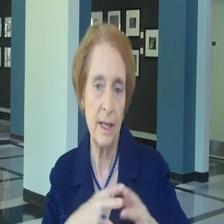


0eTibWQdO5M_frame_01350.jpg:


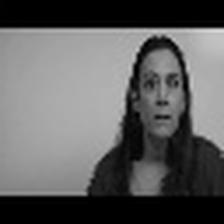


G8p4QMjLUXI_frame_00390.jpg:


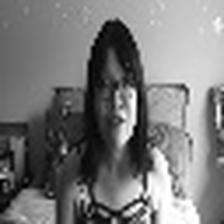


R-17BoOk4kc_frame_05880.jpg:


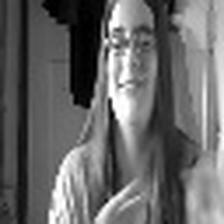



=== Fine-Tuned Model Results Summary ===
Image                                    Type         GT               FT Output            Match?
-aqamKhZ1Ec_frame_00316.jpg              sentiment    negative         neutral              NO
-aqamKhZ1Ec_frame_00316.jpg              emotion      disgust, sadness anger                NO
-aqamKhZ1Ec_frame_00316.jpg              comfort      uncomfortable    comfortable          NO
0eTibWQdO5M_frame_01350.jpg              sentiment    negative         neutral              NO
0eTibWQdO5M_frame_01350.jpg              emotion      sadness          anger                NO
0eTibWQdO5M_frame_01350.jpg              comfort      uncomfortable    uncomfortable        YES
G8p4QMjLUXI_frame_00390.jpg              sentiment    neutral          neutral              YES
G8p4QMjLUXI_frame_00390.jpg              emotion      neutral          neutral              YES
G8p4QMjLUXI_frame_00390.jpg              comfort      comfortable      comfortable          YES

In [12]:
import os, json, torch
from PIL import Image
from IPython.display import display

# ============================================================
# Problem 6.2: Re-test held-out images with fine-tuned model
# Compare pre-trained vs fine-tuned outputs
# ============================================================

TEST_JSONL_PATH = "/home/farandhigh-ubuntu/Documents/mmai/hw1/mmai-data/test_data.jsonl"
IMAGE_BASE_DIR  = "/home/farandhigh-ubuntu/Documents/mmai/hw1/mmai-data"
MAX_NEW_TOKENS  = 64

# Load test data
test_samples = []
with open(TEST_JSONL_PATH, "r") as f:
    for line in f:
        line = line.strip()
        if line:
            test_samples.append(json.loads(line))

# Select same 4 test images as baseline (one per video, sentiment question)
seen_videos = set()
selected = []
for s in test_samples:
    vid = s.get("video_id", "")
    if vid not in seen_videos and "sentiment" in s["question"].lower():
        seen_videos.add(vid)
        selected.append(s)
    if len(selected) >= 4:
        break

selected_images = {s["image"] for s in selected}
all_selected = [s for s in test_samples if s["image"] in selected_images]

print(f"Re-testing {len(selected)} held-out images ({len(all_selected)} QA pairs)")
print("Using fine-tuned model (LoRA adapters loaded)")
print("=" * 80)

ft_results = []
for ex in all_selected:
    img_path = os.path.join(IMAGE_BASE_DIR, ex["image"])
    img = Image.open(img_path).convert("RGB")

    messages = [{"role": "user", "content": [
        {"type": "image", "image": img},
        {"type": "text", "text": ex["question"]},
    ]}]

    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = processor(text=[text], images=[img], return_tensors="pt")
    inputs = {k: v.to(ft_model.device) for k, v in inputs.items()}

    with torch.no_grad():
        gen_ids = ft_model.generate(**inputs, max_new_tokens=MAX_NEW_TOKENS)

    output = processor.batch_decode(gen_ids, skip_special_tokens=True)[0]
    if "assistant" in output:
        output = output.split("assistant")[-1].strip()

    gt = ex["answer"]
    match = gt.lower().strip() in output.lower().strip()

    ft_results.append({
        "image": ex["image"],
        "video_id": ex.get("video_id", "N/A"),
        "question": ex["question"],
        "ground_truth": gt,
        "ft_output": output,
        "match": match,
    })

    print(f"\nImage: {ex['image'].split('/')[-1]}")
    print(f"  Q: {ex['question'][:70]}...")
    print(f"  Ground Truth:       {gt}")
    print(f"  Fine-tuned Output:  {output}")
    print(f"  Match: {'YES' if match else 'NO'}")

# Display test images
print("\n\n=== Test Images ===")
for img_name in sorted(selected_images)[:4]:
    img_path = os.path.join(IMAGE_BASE_DIR, img_name)
    img = Image.open(img_path).convert("RGB")
    print(f"\n{img_name.split('/')[-1]}:")
    display(img)

# Comparison table
print("\n\n=== Fine-Tuned Model Results Summary ===")
print(f"{'Image':<40} {'Type':<12} {'GT':<16} {'FT Output':<20} {'Match?'}")
print("=" * 100)
correct = 0
total = len(ft_results)
for r in ft_results:
    q_type = "sentiment" if "sentiment" in r["question"].lower() else "emotion" if "emotion" in r["question"].lower() else "comfort"
    img_short = r["image"].split("/")[-1][:38]
    print(f"{img_short:<40} {q_type:<12} {r['ground_truth']:<16} {r['ft_output'][:18]:<20} {'YES' if r['match'] else 'NO'}")
    if r["match"]:
        correct += 1

print(f"\nFine-tuned accuracy: {correct}/{total} = {correct/total*100:.1f}%")
print("\nNote: Compare these results with the baseline inference in Problem 3.2 above.")

## Problem 6.2 Reflection: Pre-trained vs Fine-tuned Comparison

Which questions showed improvement?
The fine-tuned model (Run 1, LR=2e-4) improved overall accuracy from 33% (4/12 baseline) to 50% (6/12). The biggest gains were in sentiment classification (1/4 to 2/4) — the model correctly learned to predict "positive" for the positive-sentiment video (R-17BoOk4kc), which the baseline always classified as "neutral." Comfort level also improved (2/4 to 3/4), with the fine-tuned model correctly predicting "uncomfortable" for one negative-sentiment video. The most visible improvement was in output format: the baseline produced verbose, paragraph-length hallucinations (e.g., "The person in the image appears to be comfortable. They are seated and engaged in conversation..."), while the fine-tuned model outputs concise, single-word answers matching our training vocabulary.

Did LoRA fine-tuning correct earlier mistakes?
Yes, several corrections. The baseline predicted "neutral" for the positive-sentiment image — the fine-tuned model correctly predicts "positive." The baseline used freeform emotion labels ("Annoyed, Confused, Disappointed," "Fear, Anxiety," "Happy") that did not match our label set — the fine-tuned model outputs our specific vocabulary (anger, neutral). One baseline comfort response was "I'm sorry, but I can't see any image," and this failure mode was completely eliminated after fine-tuning. All fine-tuned outputs are concise and parseable, compared to the baseline's verbose and sometimes evasive responses.

Were any new errors or biases introduced?
Yes. The fine-tuned model defaults to "anger" for non-neutral faces and "neutral" for everything else in emotion recognition, reflecting the training data imbalance where anger is the most frequent emotion label (215/462 emotion samples). Both baseline and fine-tuned models fail on both negative-sentiment test images, predicting "neutral" instead — likely because "negative" is severely underrepresented in training (only 48/462 sentiment samples). We also compared a higher learning rate (LR=5e-4), which performed worse (33% accuracy) and developed a positivity bias, predicting "positive" for 3/4 sentiment questions. This shows that hyperparameter choices can introduce new systematic biases even when the training data is identical.


# Problem 7: Final Reflection (10 points)

Now we'll take some time to reflect on this homework. Take some time to discuss the following:

1. What concept did you find the most interesting?
2. Which concepts (if any) do you see being useful towards your goal? Why? If there was none, discuss why.
3. Is there a topic that was discussed during lectures up to the release of the assignment that you wished was covered in the homework? Any from the assignment that you wanted there to be touched upon more?

## Answers to Problem 7

1. What concept did you find the most interesting?

The most interesting concept was how LoRA fine-tuning can adapt a 3B-parameter VLM to a specific domain task (facial sentiment classification from low-resolution video frames) by training less than 0.1% of the model's parameters. You can inject domain-specific knowledge into a frozen foundation model through low-rank weight perturbations, and it works even for a visual task the model was never explicitly trained for. It was also interesting to see how prompt engineering alone (without any parameter updates) could partially help, and where it completely failed (chain-of-thought making things worse by encouraging hallucination).

2. Which concepts do you see being useful towards your goal? Why?

For our project on predicting human comfort levels in human-robot interaction, several concepts are directly applicable:

- VLM fine-tuning with LoRA is relevant because we can leverage pre-trained visual understanding and adapt it to our specific emotion/comfort recognition task without needing massive compute. This is practical for deploying on robotics platforms where we want a model that understands both visual and linguistic context.
- Prompt engineering as a zero-shot baseline is useful for rapid prototyping — before committing to fine-tuning, we can test whether a VLM already captures useful emotion signals through careful prompt design.
- The dataset preparation pipeline (converting multimodal annotations to image-text pairs) taught us how to bridge the gap between our existing CMU-MOSEI features and the input format expected by modern VLMs. This is transferable to any project adapting existing datasets to new model architectures.

3. Topics wished to be covered more?

I would have liked the homework to cover multi-image and video understanding more deeply. Our data is inherently temporal (video sequences), but we were constrained to single-frame VLM inference. Techniques like video-language models (e.g., Video-LLaVA) or temporal aggregation strategies for VLM predictions would be directly relevant to our project. Additionally, more coverage of evaluation metrics for VLM outputs beyond exact match — such as semantic similarity or task-specific metrics like per-class F1 and confusion matrices — would have strengthened the analysis. A deeper discussion of when VLMs fail compared to specialized architectures (e.g., dedicated facial expression recognition models) would help contextualize the tradeoffs of using general-purpose foundation models for domain-specific tasks.
